In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 12
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_test"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [43]:
# Only record build and update in dynamic

ion_mode = [1, -1]


num_per_group=[1_000_000, 3_000_000, 10_000_000, 30_000_000, 100_000_000, 300_000_000]


In [44]:
import matplotlib.ticker as ticker

df=[]
for group_size in num_per_group:
    data={"num_per_group":group_size, "number_of_spectra_per_file":1_000_000, "number_of_files":100}
    for charge in ion_mode:
        path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_memory_usage_options_{group_size}_num_per_group_not_convert.txt"
        
        with open(path_benchmark_specific_data_dynamic,"r") as f1:
            for line in f1.readlines():
                items=line.split(":", maxsplit=1)
                key, value=items
                if key.strip()=="Maximum resident set size (kbytes)":
                    dynamic=int(value.strip())

        data["dynamic_entropy_search(fast_update)"]=dynamic/1048576
        data["charge"]=charge
        
        df.append(pd.DataFrame([data]))
    
df=pd.concat(df)
df

,num_per_group,number_of_spectra_per_file,number_of_files,dynamic_entropy_search(fast_update),charge
0,1000000,1000000,100,10.411762,1
0,1000000,1000000,100,6.042168,-1
0,3000000,1000000,100,10.411133,1
0,3000000,1000000,100,6.044186,-1
0,10000000,1000000,100,10.440762,1
0,10000000,1000000,100,6.067009,-1
0,30000000,1000000,100,10.450245,1
0,30000000,1000000,100,6.082237,-1
0,100000000,1000000,100,10.441502,1
0,100000000,1000000,100,6.084614,-1


In [45]:

df_data = df[["num_per_group", 
              "charge",
            "dynamic_entropy_search(fast_update)", 
]]

df_melted=df_data.melt(id_vars=["charge", "num_per_group"], var_name="type", value_name="memory_usage")
df_melted

,charge,num_per_group,type,memory_usage
0,1,1000000,dynamic_entropy_search(fast_update),10.411762
1,-1,1000000,dynamic_entropy_search(fast_update),6.042168
2,1,3000000,dynamic_entropy_search(fast_update),10.411133
3,-1,3000000,dynamic_entropy_search(fast_update),6.044186
4,1,10000000,dynamic_entropy_search(fast_update),10.440762
5,-1,10000000,dynamic_entropy_search(fast_update),6.067009
6,1,30000000,dynamic_entropy_search(fast_update),10.450245
7,-1,30000000,dynamic_entropy_search(fast_update),6.082237
8,1,100000000,dynamic_entropy_search(fast_update),10.441502
9,-1,100000000,dynamic_entropy_search(fast_update),6.084614


In [ ]:
def plot_memory_options_num_per_group_not_convert(
        df,
        color_palette,
        ylim,
        save_path
):
#     df_charge=df_melted[df_melted["charge"]==charge]
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x="num_per_group", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, palette=color_palette,
                legend=True, width=0.4, errwidth=0)
    bottom=ylim[0]
    top=ylim[1]
    plt.ylim(top=top,bottom=bottom)
    ax = plt.gca()
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    new_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(new_labels)
    plt.xticks(rotation=30)
    plt.ylabel(f"Memory usage of building index (GB)")
    plt.xlabel(f"Size of group")
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ['(+)ESI' if label == '1' else '(-)ESI' for label in labels]
    ax.legend(handles, custom_labels,loc='upper center',bbox_to_anchor=(0.5,1.2), framealpha=0.9, ncol=2,frameon=False, )
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

In [47]:
color_palette={
    1: '#ca3032',
    -1:"#32586d"
}

/tmp/ipykernel_2946434/2461229250.py:9: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x="num_per_group", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, palette=color_palette,
/tmp/ipykernel_2946434/2461229250.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


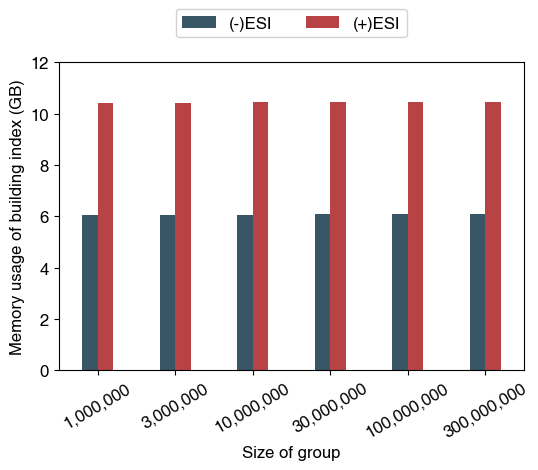

In [50]:
# chrge=-1
ylim=(0,12)
save_path=path_figures / f"memory_usage_options_num_per_group_not_convert.svg"
plot_memory_options_num_per_group_not_convert(
    df=df,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)

/tmp/ipykernel_2946434/4226732084.py:10: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x="num_per_group", y="memory_usage", hue="type", data=df_charge, palette=color_palette,
/tmp/ipykernel_2946434/4226732084.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


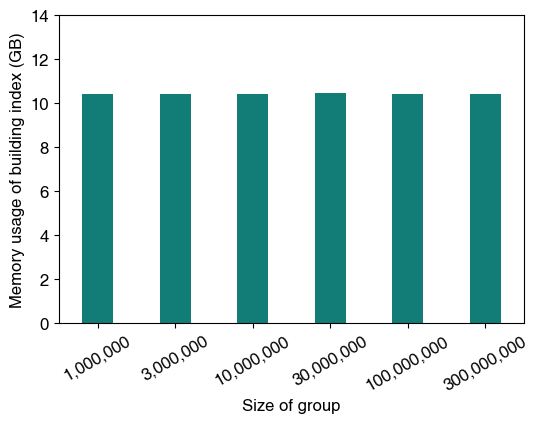

In [41]:
charge=1
ylim=(0,14)
save_path=path_figures / f"memory_usage_{charge}_options_num_per_group_not_convert.svg"
plot_memory_options_num_per_group_not_convert(
    df_melted=df_melted,
    charge=charge,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)